In [1]:

import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score

# Getting the data

In [2]:
df=pd.read_csv(f"/content/drive/MyDrive/iti data/house_prices.csv")

# Dataset Overview

In [3]:
df.head(10)

,Index,Title,Description,Amount(in rupees),Price (in rupees),location,Carpet Area,Status,Floor,Transaction,...,facing,overlooking,Society,Bathroom,Balcony,Car Parking,Ownership,Super Area,Dimensions,Plot Area
0,0,1 BHK Ready to Occupy Flat for sale in Srushti...,"Bhiwandi, Thane has an attractive 1 BHK Flat f...",42 Lac,6000.0,thane,500 sqft,Ready to Move,10 out of 11,Resale,...,NaN,NaN,Srushti Siddhi Mangal Murti Complex,1,2,NaN,NaN,NaN,NaN,NaN
1,1,2 BHK Ready to Occupy Flat for sale in Dosti V...,One can find this stunning 2 BHK flat for sale...,98 Lac,13799.0,thane,473 sqft,Ready to Move,3 out of 22,Resale,...,East,Garden/Park,Dosti Vihar,2,NaN,1 Open,Freehold,NaN,NaN,NaN
2,2,2 BHK Ready to Occupy Flat for sale in Sunrise...,Up for immediate sale is a 2 BHK apartment in ...,1.40 Cr,17500.0,thane,779 sqft,Ready to Move,10 out of 29,Resale,...,East,Garden/Park,Sunrise by Kalpataru,2,NaN,1 Covered,Freehold,NaN,NaN,NaN
3,3,1 BHK Ready to Occupy Flat for sale Kasheli,This beautiful 1 BHK Flat is available for sal...,25 Lac,NaN,thane,530 sqft,Ready to Move,1 out of 3,Resale,...,NaN,NaN,NaN,1,1,NaN,NaN,NaN,NaN,NaN
4,4,2 BHK Ready to Occupy Flat for sale in TenX Ha...,"This lovely 2 BHK Flat in Pokhran Road, Thane ...",1.60 Cr,18824.0,thane,635 sqft,Ready to Move,20 out of 42,Resale,...,West,"Garden/Park, Main Road",TenX Habitat Raymond Realty,2,NaN,1 Covered,Co-operative Society,NaN,NaN,NaN
5,5,1 BHK Ready to Occupy Flat for sale in Virat A...,Creatively planned and constructed is a 1 BHK ...,45 Lac,6618.0,thane,NaN,Ready to Move,2 out of 7,Resale,...,East,"Garden/Park, Main Road",Virat Aangan,1,1,NaN,Co-operative Society,680 sqft,NaN,NaN
6,6,1 BHK Ready to Occupy Flat for sale Mumbra,This magnificent 1 BHK Flat is available for s...,16.5 Lac,2538.0,thane,550 sqft,Ready to Move,4 out of 5,Resale,...,NaN,NaN,NaN,1,NaN,NaN,NaN,NaN,NaN,NaN
7,7,1 BHK Ready to Occupy Flat for sale Kalwa,Creatively planned and constructed is a 1 BHK ...,60 Lac,10435.0,thane,NaN,Ready to Move,Ground out of 7,Resale,...,NaN,NaN,NaN,1,NaN,NaN,NaN,575 sqft,NaN,NaN
8,8,1 BHK Ready to Occupy Flat for sale Kalwa,Discover this immaculate 1 BHK flat for sale a...,60 Lac,10000.0,thane,NaN,Ready to Move,Ground out of 2,Resale,...,NaN,NaN,NaN,1,NaN,NaN,Co-operative Society,600 sqft,NaN,NaN
9,9,3 BHK Ready to Occupy Flat for sale in Pride P...,One can find this stunning 3 BHK flat for sale...,1.60 Cr,11150.0,thane,900 sqft,Ready to Move,3 out of 27,Resale,...,East,Garden/Park,Pride Palms,3,1,1 Covered,Freehold,NaN,NaN,NaN


In [4]:
df["Car Parking"].value_counts()

,count
Car Parking,
1 Covered,38754
"1 Covered,",16991
2 Covered,10691
1 Open,7873
"2 Covered,",3978
...,...
206 Covered,1
205 Covered,1
"11 Covered,",1


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 187531 entries, 0 to 187530
Data columns (total 21 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Index              187531 non-null  int64  
 1   Title              187531 non-null  object 
 2   Description        184508 non-null  object 
 3   Amount(in rupees)  187531 non-null  object 
 4   Price (in rupees)  169866 non-null  float64
 5   location           187531 non-null  object 
 6   Carpet Area        106858 non-null  object 
 7   Status             186916 non-null  object 
 8   Floor              180454 non-null  object 
 9   Transaction        187448 non-null  object 
 10  Furnishing         184634 non-null  object 
 11  facing             117298 non-null  object 
 12  overlooking        106095 non-null  object 
 13  Society            77853 non-null   object 
 14  Bathroom           186703 non-null  object 
 15  Balcony            138596 non-null  object 
 16  Ca

In [6]:
df.shape

(187531, 21)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 187531 entries, 0 to 187530
Data columns (total 21 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Index              187531 non-null  int64  
 1   Title              187531 non-null  object 
 2   Description        184508 non-null  object 
 3   Amount(in rupees)  187531 non-null  object 
 4   Price (in rupees)  169866 non-null  float64
 5   location           187531 non-null  object 
 6   Carpet Area        106858 non-null  object 
 7   Status             186916 non-null  object 
 8   Floor              180454 non-null  object 
 9   Transaction        187448 non-null  object 
 10  Furnishing         184634 non-null  object 
 11  facing             117298 non-null  object 
 12  overlooking        106095 non-null  object 
 13  Society            77853 non-null   object 
 14  Bathroom           186703 non-null  object 
 15  Balcony            138596 non-null  object 
 16  Ca

In [8]:
# Percentage of missing values in columns

( df.isnull().sum() / len(df) ) *100

,0
Index,0.000000
Title,0.000000
Description,1.612000
Amount(in rupees),0.000000
Price (in rupees),9.419776
location,0.000000
Carpet Area,43.018488
Status,0.327946
Floor,3.773776
Transaction,0.044259


In [9]:
high_missing_value_columns=['Dimensions','Plot Area','Society','Car Parking']

In [10]:
df['Status'].value_counts()

# contains only a single unique value across all rows

,count
Status,
Ready to Move,186916


In [11]:
df.duplicated().sum()

np.int64(0)

In [12]:
df.describe()

,Index,Price (in rupees),Dimensions,Plot Area
count,187531.000000,1.698660e+05,0.0,0.0
mean,93765.000000,7.583772e+03,NaN,NaN
std,54135.681003,2.724171e+04,NaN,NaN
min,0.000000,0.000000e+00,NaN,NaN
25%,46882.500000,4.297000e+03,NaN,NaN
50%,93765.000000,6.034000e+03,NaN,NaN
75%,140647.500000,9.450000e+03,NaN,NaN
max,187530.000000,6.700000e+06,NaN,NaN


In [13]:
df.describe(include='object')

,Title,Description,Amount(in rupees),location,Carpet Area,Status,Floor,Transaction,Furnishing,facing,overlooking,Society,Bathroom,Balcony,Car Parking,Ownership,Super Area
count,187531,184508,187531,187531,106858,186916,180454,187448,184634,117298,106095,77853,186703,138596,84174,122014,79846
unique,32446,65634,1561,81,2758,1,947,4,3,8,19,10376,11,11,229,4,2976
top,2 BHK Ready to Occupy Flat for sale in Divyasr...,Multistorey apartment is available for sale. I...,Call for Price,new-delhi,1000 sqft,Ready to Move,2 out of 4,Resale,Semi-Furnished,East,Main Road,Hamdam Apartment,2,2,1 Covered,Freehold,1100 sqft
freq,2106,2732,9684,27599,5285,186916,12433,144172,88318,54741,32193,1648,93007,51809,38754,112229,2599


In [14]:
Numerical_features=df.describe().columns
print(list(Numerical_features))

['Index', 'Price (in rupees)', 'Dimensions', 'Plot Area']


In [15]:
Categorical_Features=df.columns.difference(list(Numerical_features))

print(Categorical_Features)
print(len(Categorical_Features))

Index(['Amount(in rupees)', 'Balcony', 'Bathroom', 'Car Parking',
       'Carpet Area', 'Description', 'Floor', 'Furnishing', 'Ownership',
       'Society', 'Status', 'Super Area', 'Title', 'Transaction', 'facing',
       'location', 'overlooking'],
      dtype='object')
17


--> the dataset has (187531, 21) (rows,columns)

--> **numeric columns** : [ " Index " ,	" Price (in rupees) " , " Dimensions " ,	"    Plot Area "]


--> **categorical columns** : ['Amount(in rupees)', 'Balcony', 'Bathroom', 'Car Parking',
       'Carpet Area', 'Description', 'Floor', 'Furnishing', 'Ownership',
       'Society', 'Status', 'Super Area', 'Title', 'Transaction', 'facing',
       'location', 'overlooking']


--> **high_missing_value_columns**=[" Dimensions " , " Plot Area " , " Super Area " , " Car Parking " , " Society "]


# Cleaning Data / Exploratory Data Analysis (EDA)

**there are some messy columns that contain mixed text ( text and numbers ) so we need to clean them and extracting specific inforamtion that we need from them before doing (EDA)**

In [16]:
# dropping columns

df=df.drop(columns=high_missing_value_columns)  # high missing values columns --> ['Dimensions','Plot Area','Car Parking','Society']

df= df.drop(columns=['Index']) # not useful column

df= df.drop(columns=['Status']) # contains only a single unique value across all rows it has zero variance and provides no predictive power to model.


In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 187531 entries, 0 to 187530
Data columns (total 15 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Title              187531 non-null  object 
 1   Description        184508 non-null  object 
 2   Amount(in rupees)  187531 non-null  object 
 3   Price (in rupees)  169866 non-null  float64
 4   location           187531 non-null  object 
 5   Carpet Area        106858 non-null  object 
 6   Floor              180454 non-null  object 
 7   Transaction        187448 non-null  object 
 8   Furnishing         184634 non-null  object 
 9   facing             117298 non-null  object 
 10  overlooking        106095 non-null  object 
 11  Bathroom           186703 non-null  object 
 12  Balcony            138596 non-null  object 
 13  Ownership          122014 non-null  object 
 14  Super Area         79846 non-null   object 
dtypes: float64(1), object(14)
memory usage: 21.5+ MB


In [18]:
'''
Convert to a number (1 Lac = 100,000 ₹; 1 Cr = 10,000,000 ₹) and drop rows
without a usable price.

'''

def parse_amount(x):
    if not isinstance(x, str):
        return None

    x = x.strip().lower()

    try:
        if "lac" in x:
            return float(x.replace("lac", "").strip()) * 1e5

        if "cr" in x:
            return float(x.replace("cr", "").strip()) * 1e7

        return float(x.replace(",", ""))

    except ValueError:
        return None


df["price_clean"] = df["Amount(in rupees)"].apply(parse_amount)

df = df.dropna(subset=["price_clean"])

In [19]:
#  normalise the unit to sqft

def parse_sqft(x):
    if pd.isna(x):
        return np.nan
    m = re.search(r"([\d,.]+)", str(x))
    return float(m.group(1).replace(",", "")) if m else np.nan

In [20]:
df["carpet_area_sqft"] = df["Carpet Area"].apply(parse_sqft)
df["super_area_sqft"] = df["Super Area"].apply(parse_sqft)

In [21]:
# we will combine  ("Carpet Area" and "Super Area") into one feature (area_sqft).

# the primary feature will be "Carpet Area" because it is the most accurate representation of a property's true usable size.

# However, if a listing is missing its Carpet Area but has a Super Area,we will impute the carpet area with the super area



# unified area: prefer carpet area, fall back to super area
df["area_sqft"] = df["carpet_area_sqft"].fillna(df["super_area_sqft"])
df["area_source"] = np.where(
    df["carpet_area_sqft"].notna(), "carpet",
    np.where(df["super_area_sqft"].notna(), "super", "missing")
)

In [22]:
df

,Title,Description,Amount(in rupees),Price (in rupees),location,Carpet Area,Floor,Transaction,Furnishing,facing,overlooking,Bathroom,Balcony,Ownership,Super Area,price_clean,carpet_area_sqft,super_area_sqft,area_sqft,area_source
0,1 BHK Ready to Occupy Flat for sale in Srushti...,"Bhiwandi, Thane has an attractive 1 BHK Flat f...",42 Lac,6000.0,thane,500 sqft,10 out of 11,Resale,Unfurnished,NaN,NaN,1,2,NaN,NaN,4200000.0,500.0,NaN,500.0,carpet
1,2 BHK Ready to Occupy Flat for sale in Dosti V...,One can find this stunning 2 BHK flat for sale...,98 Lac,13799.0,thane,473 sqft,3 out of 22,Resale,Semi-Furnished,East,Garden/Park,2,NaN,Freehold,NaN,9800000.0,473.0,NaN,473.0,carpet
2,2 BHK Ready to Occupy Flat for sale in Sunrise...,Up for immediate sale is a 2 BHK apartment in ...,1.40 Cr,17500.0,thane,779 sqft,10 out of 29,Resale,Unfurnished,East,Garden/Park,2,NaN,Freehold,NaN,14000000.0,779.0,NaN,779.0,carpet
3,1 BHK Ready to Occupy Flat for sale Kasheli,This beautiful 1 BHK Flat is available for sal...,25 Lac,NaN,thane,530 sqft,1 out of 3,Resale,Unfurnished,NaN,NaN,1,1,NaN,NaN,2500000.0,530.0,NaN,530.0,carpet
4,2 BHK Ready to Occupy Flat for sale in TenX Ha...,"This lovely 2 BHK Flat in Pokhran Road, Thane ...",1.60 Cr,18824.0,thane,635 sqft,20 out of 42,Resale,Unfurnished,West,"Garden/Park, Main Road",2,NaN,Co-operative Society,NaN,16000000.0,635.0,NaN,635.0,carpet
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
187526,3 BHK Ready to Occupy Flat for sale in Bollywo...,This magnificent 3 BHK Flat is available for s...,63 Lac,3225.0,zirakpur,NaN,2 out of 4,New Property,Semi-Furnished,East,Garden/Park,3,3,Freehold,1953 sqft,6300000.0,NaN,1953.0,1953.0,super
187527,3 BHK Ready to Occupy Flat for sale in Sushma ...,Have a look at this immaculate 3 BHK flat for ...,55 Lac,3274.0,zirakpur,NaN,4 out of 6,Resale,Unfurnished,North - East,"Garden/Park, Main Road",3,NaN,NaN,1680 sqft,5500000.0,NaN,1680.0,1680.0,super
187528,3 BHK Ready to Occupy Flat for sale in Bollywo...,"Gazipur, Zirakpur has an appealing 3 BHK flat ...",76 Lac,4343.0,zirakpur,1250 sqft,1 out of 3,Resale,Furnished,East,"Garden/Park, Main Road",3,2,Freehold,NaN,7600000.0,1250.0,NaN,1250.0,carpet
187529,2 BHK Ready to Occupy Flat for sale in Friends...,Up for immediate sale is a 2 BHK apartment in ...,30 Lac,4231.0,zirakpur,NaN,2 out of 2,Resale,Semi-Furnished,NaN,Main Road,2,NaN,NaN,709 sqft,3000000.0,NaN,709.0,709.0,super


In [23]:
df1=df.copy()

In [24]:
#  extract the floor number

def parse_floor(x):
    if pd.isna(x):
        return (np.nan, np.nan)
    x = str(x)
    m = re.match(r"(Ground|\d+)\s*out of\s*(\d+)", x, flags=re.IGNORECASE)
    if not m:
        return (np.nan, np.nan)
    cur = 0 if m.group(1).lower() == "ground" else float(m.group(1))
    total = float(m.group(2))
    return (cur, total)

floor_parsed = df["Floor"].apply(parse_floor)
df["current_floor"] = floor_parsed.apply(lambda t: t[0])
df["total_floors"] = floor_parsed.apply(lambda t: t[1])

In [25]:
def parse_count(x):
    if pd.isna(x):
        return np.nan
    x = str(x).strip()
    if x == "> 10":
        return 11
    try:
        return float(x)
    except ValueError:
        return np.nan

df["bathroom"] = df["Bathroom"].apply(parse_count)
df["balcony"] = df["Balcony"].apply(parse_count)


In [26]:
'''
BHK mean (Bedroom, Hall, and Kitchen) and The number preceding "BHK" indicates the specific count of bedrooms.
so here we extract the number of bedroom in new columns

'''


df["bhk"] = df["Title"].str.extract(r"(\d+)\s*BHK").astype(float)




In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 177847 entries, 0 to 187530
Data columns (total 25 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Title              177847 non-null  object 
 1   Description        174918 non-null  object 
 2   Amount(in rupees)  177847 non-null  object 
 3   Price (in rupees)  169866 non-null  float64
 4   location           177847 non-null  object 
 5   Carpet Area        101522 non-null  object 
 6   Floor              170898 non-null  object 
 7   Transaction        177780 non-null  object 
 8   Furnishing         175780 non-null  object 
 9   facing             112111 non-null  object 
 10  overlooking        102022 non-null  object 
 11  Bathroom           177087 non-null  object 
 12  Balcony            130688 non-null  object 
 13  Ownership          115922 non-null  object 
 14  Super Area         76235 non-null   object 
 15  price_clean        177847 non-null  float64
 16  carpet_

**After generation new versions of the columns, the old ones will be dropped :**

==> ['Super Area','Balcony','Bathroom','Floor','Carpet Area','Amount(in rupees)','Title']

In [28]:
df=df.drop(columns=['Super Area','Balcony','Bathroom','Floor','Carpet Area','Amount(in rupees)','Title','carpet_area_sqft','super_area_sqft','Price (in rupees)','Description','overlooking'])

In [29]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 177847 entries, 0 to 187530
Data columns (total 13 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   location       177847 non-null  object 
 1   Transaction    177780 non-null  object 
 2   Furnishing     175780 non-null  object 
 3   facing         112111 non-null  object 
 4   Ownership      115922 non-null  object 
 5   price_clean    177847 non-null  float64
 6   area_sqft      177757 non-null  float64
 7   area_source    177847 non-null  object 
 8   current_floor  170518 non-null  float64
 9   total_floors   170518 non-null  float64
 10  bathroom       177087 non-null  float64
 11  balcony        130688 non-null  float64
 12  bhk            177528 non-null  float64
dtypes: float64(7), object(6)
memory usage: 19.0+ MB


In [30]:
df.head(5)

,location,Transaction,Furnishing,facing,Ownership,price_clean,area_sqft,area_source,current_floor,total_floors,bathroom,balcony,bhk
0,thane,Resale,Unfurnished,NaN,NaN,4200000.0,500.0,carpet,10.0,11.0,1.0,2.0,1.0
1,thane,Resale,Semi-Furnished,East,Freehold,9800000.0,473.0,carpet,3.0,22.0,2.0,NaN,2.0
2,thane,Resale,Unfurnished,East,Freehold,14000000.0,779.0,carpet,10.0,29.0,2.0,NaN,2.0
3,thane,Resale,Unfurnished,NaN,NaN,2500000.0,530.0,carpet,1.0,3.0,1.0,1.0,1.0
4,thane,Resale,Unfurnished,West,Co-operative Society,16000000.0,635.0,carpet,20.0,42.0,2.0,NaN,2.0


# Handle missing values

In [31]:
# Numerical features
num_cols = ["area_sqft", "bathroom", "balcony", "current_floor", "total_floors"]
for col in num_cols:
    df[col] = df.groupby(["location", "bhk"])[col].transform(
        lambda s: s.fillna(s.median())
    )
    df[col] = df[col].fillna(df[col].median())

In [32]:
# Categorical: explicit "Unknown"
cat_cols = ["Transaction", "Furnishing", "facing", "Ownership", "overlooking"]
for col in cat_cols:
    if col in df.columns:
        df[col] = df[col].fillna("Unknown")

In [33]:
df=df.dropna(subset=['bhk'])

In [34]:
df.isnull().sum()

,0
location,0
Transaction,0
Furnishing,0
facing,0
Ownership,0
price_clean,0
area_sqft,0
area_source,0
current_floor,0
total_floors,0


In [35]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 177528 entries, 0 to 187530
Data columns (total 13 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   location       177528 non-null  object 
 1   Transaction    177528 non-null  object 
 2   Furnishing     177528 non-null  object 
 3   facing         177528 non-null  object 
 4   Ownership      177528 non-null  object 
 5   price_clean    177528 non-null  float64
 6   area_sqft      177528 non-null  float64
 7   area_source    177528 non-null  object 
 8   current_floor  177528 non-null  float64
 9   total_floors   177528 non-null  float64
 10  bathroom       177528 non-null  float64
 11  balcony        177528 non-null  float64
 12  bhk            177528 non-null  float64
dtypes: float64(7), object(6)
memory usage: 19.0+ MB


In [36]:
Numerical_features=df.describe().columns
print(list(Numerical_features))

['price_clean', 'area_sqft', 'current_floor', 'total_floors', 'bathroom', 'balcony', 'bhk']


In [37]:
Categorical_Features=df.columns.difference(list(Numerical_features))

print(Categorical_Features)
print(len(Categorical_Features))

Index(['Furnishing', 'Ownership', 'Transaction', 'area_source', 'facing',
       'location'],
      dtype='object')
6


# Handling Outliers


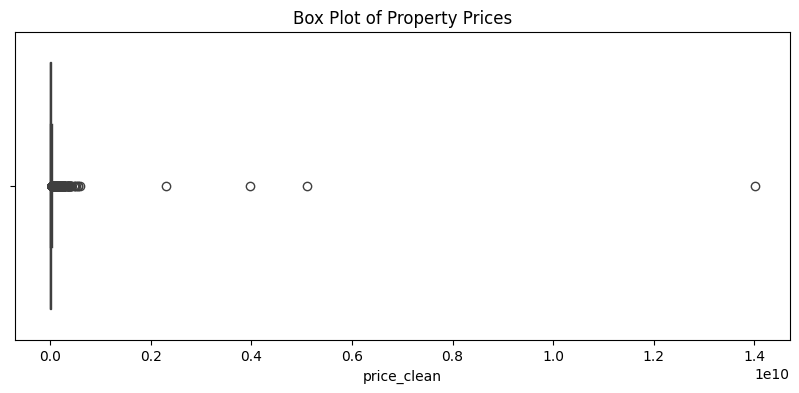

In [38]:

# Plotting a boxplot for Price

plt.figure(figsize=(10, 4))
sns.boxplot(x=df['price_clean'])
plt.title('Box Plot of Property Prices')
plt.show()

In [39]:
# 8. Outlier handling (price per sqft, IQR-based)

df["price_per_sqft"] = df["price_clean"] / df["area_sqft"]

q1, q3 = df["price_per_sqft"].quantile([0.01, 0.99])
before = len(df)
df = df[(df["price_per_sqft"] >= q1) & (df["price_per_sqft"] <= q3)]
print(f"Dropped {before - len(df)} rows as price/sqft outliers")

# also drop nonsensical areas / prices
df = df[(df["area_sqft"] > 50) & (df["area_sqft"] < 20000)]
df = df[(df["price_clean"] > 1e5) & (df["price_clean"] < 5e8)]

Dropped 3490 rows as price/sqft outliers


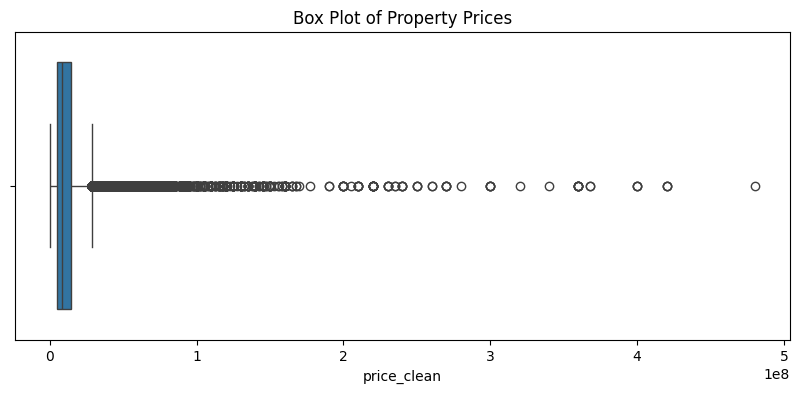

In [40]:
plt.figure(figsize=(10, 4))
sns.boxplot(x=df['price_clean'])
plt.title('Box Plot of Property Prices')
plt.show()

 # Distribution of numerical data

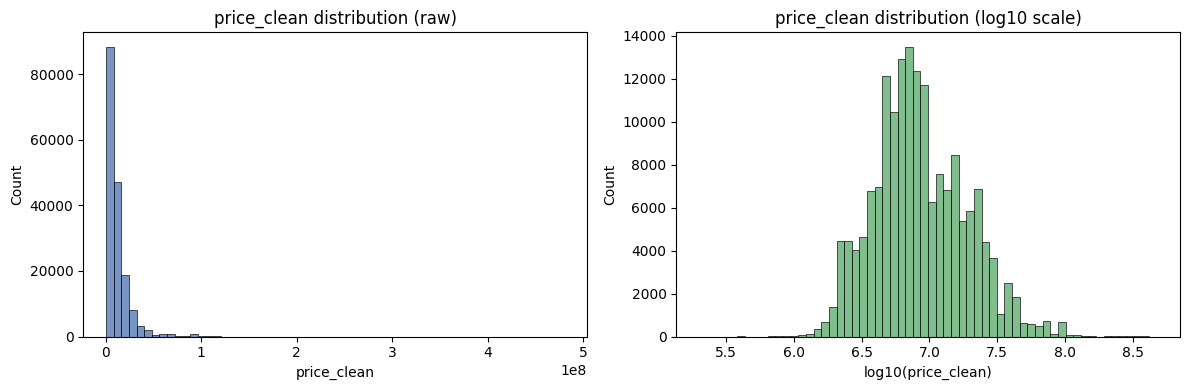

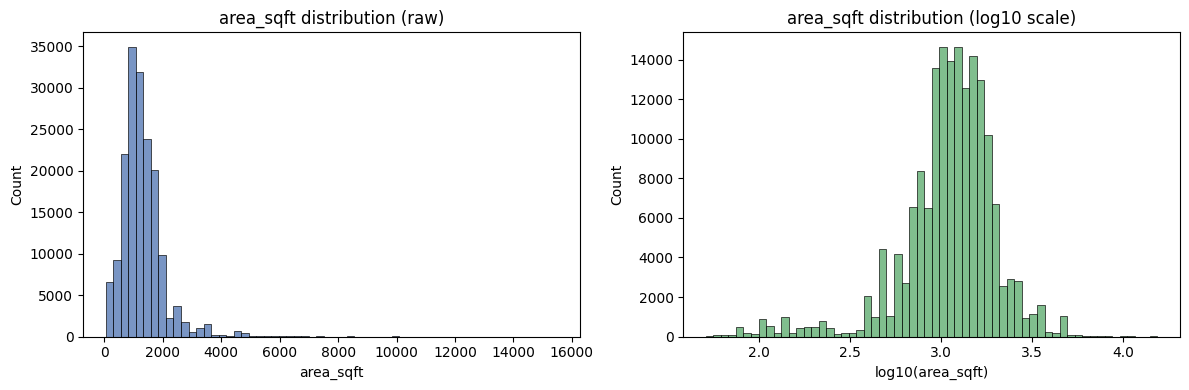

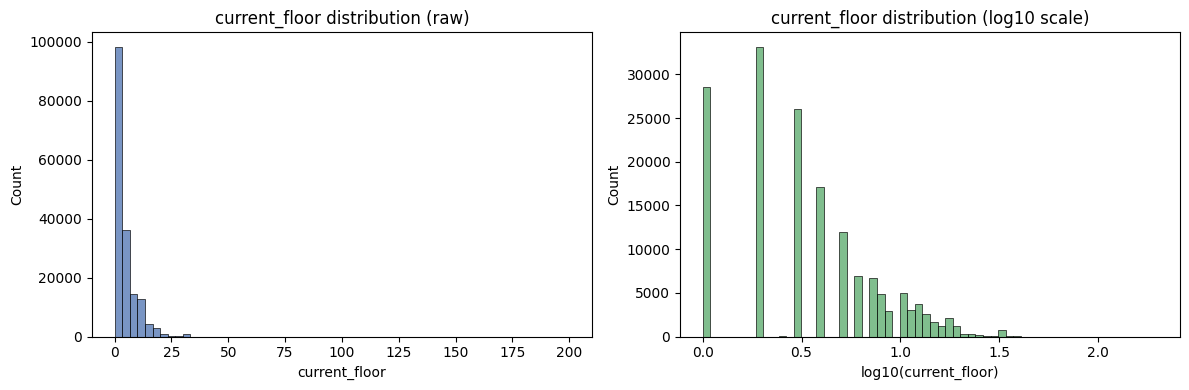

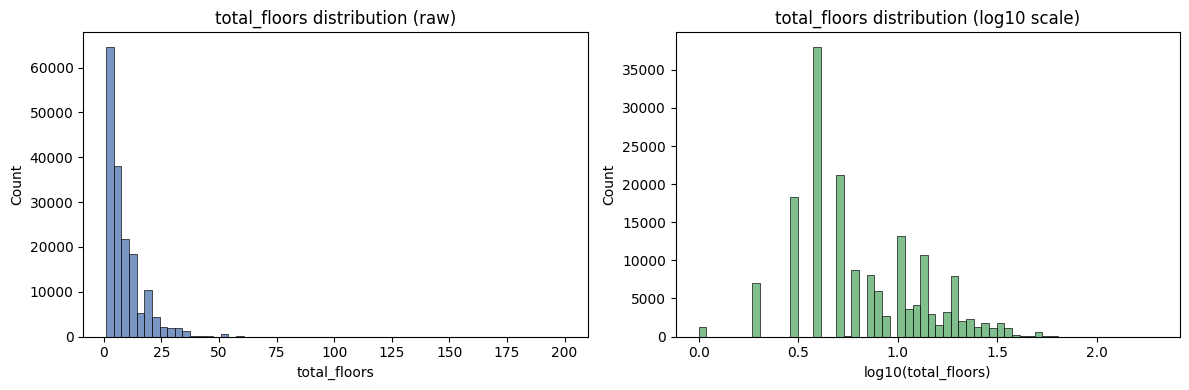

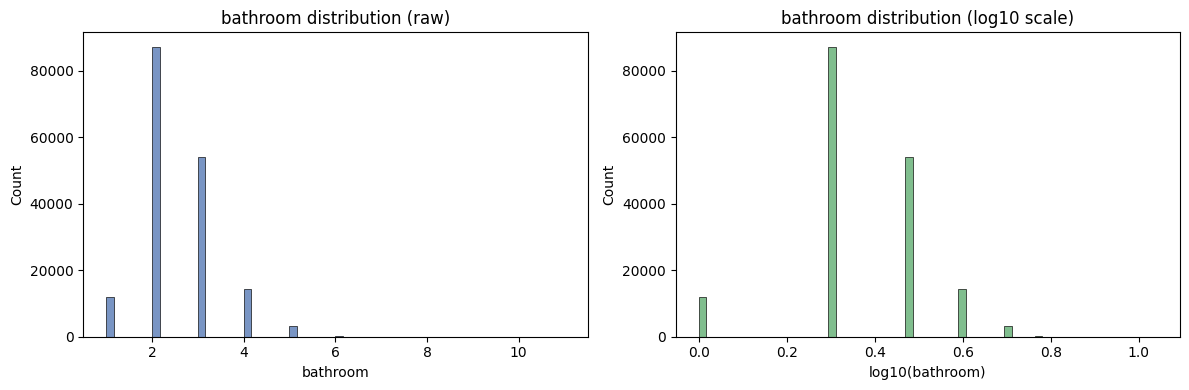

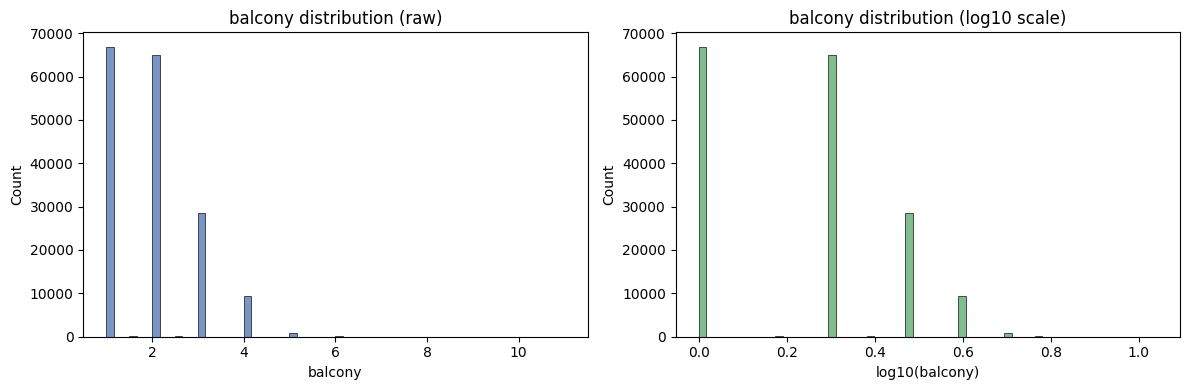

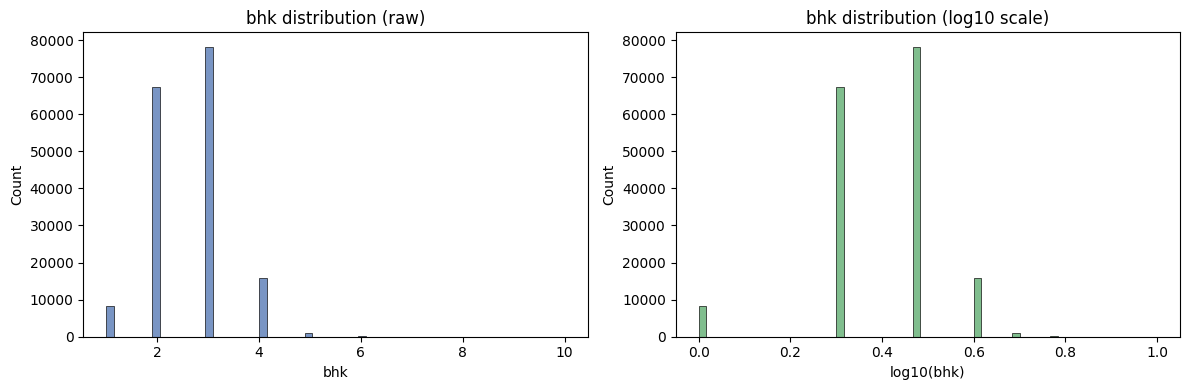

In [41]:


# Loop through each numerical column and plot raw vs log10 distributions
for col in Numerical_features:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # Raw distribution
    sns.histplot(df[col], bins=60, ax=axes[0], color="#4C72B0")
    axes[0].set_title(f"{col} distribution (raw)")
    axes[0].set_xlabel(col)

    # Log10 distribution (replace 0 with NaN to avoid -inf errors)
    log_data = np.log10(df[col].replace(0, np.nan))
    sns.histplot(log_data, bins=60, ax=axes[1], color="#55A868")
    axes[1].set_title(f"{col} distribution (log10 scale)")
    axes[1].set_xlabel(f"log10({col})")

    plt.tight_layout()
    plt.show()

In [42]:
skewed_numeric_features=['area_sqft','current_floor','total_floors']
numeric_features = ["bhk", "bathroom", "balcony"]
categorical_features = ["Furnishing", "Transaction", "Ownership", "facing","location","area_source"]

In [43]:
df=df.drop(columns='price_per_sqft')

In [44]:
df.describe(include='object')

,location,Transaction,Furnishing,facing,Ownership,area_source
count,171022,171022,171022,171022,171022,171022
unique,81,5,4,9,5,3
top,bangalore,Resale,Semi-Furnished,Unknown,Freehold,carpet
freq,23250,129243,80839,62000,103363,98515


In [45]:
# only the top-N  locations and group the rest into 'other'
high_card_cols = ["location"]
top_n = 40

for col in high_card_cols:
    if col in df.columns:

        top_cats = df[col].value_counts().nlargest(top_n).index

        df[col] = df[col].where(df[col].isin(top_cats), "other")

In [46]:
df.describe(include='object')

,location,Transaction,Furnishing,facing,Ownership,area_source
count,171022,171022,171022,171022,171022,171022
unique,41,5,4,9,5,3
top,bangalore,Resale,Semi-Furnished,Unknown,Freehold,carpet
freq,23250,129243,80839,62000,103363,98515


#Pipelines

In [47]:
# -- Numeric pipeline
numeric_pipeline = Pipeline(steps=[
    ("scaler", StandardScaler()),
])

In [48]:
# -- Categorical pipeline
categorical_pipeline = Pipeline(steps=[
    ("onehot", OneHotEncoder(handle_unknown='ignore',sparse_output=False)),
])

In [49]:
# Log-transform pipeline:
log_transform_pipeline = Pipeline(steps=[
    ("log", FunctionTransformer(np.log1p, inverse_func=np.expm1, validate=True,feature_names_out="one-to-one")),
    ("scaler", StandardScaler()),
])

In [50]:
#  Combine into one preprocessor with ColumnTransformer

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_pipeline, numeric_features),
    ("num_log", log_transform_pipeline, skewed_numeric_features),
    ("cat", categorical_pipeline, categorical_features),
])


# Splitting data into X,y then train / test

In [51]:
X = df[numeric_features + skewed_numeric_features + categorical_features]
y = df["price_clean"]

In [52]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
y = df["price_clean"]

# Model Pipeline

In [53]:
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error

In [54]:
models = {
    "Linear Regression": LinearRegression(),


    "Random Forest": RandomForestRegressor(n_estimators=200, max_depth=None,
                                            random_state=42, n_jobs=-1),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42),
    "XGBoost": XGBRegressor(n_estimators=300, max_depth=6, learning_rate=0.1,random_state=42, n_jobs=-1)

}

In [55]:
results = []
fitted_models = {}

for name, regressor in models.items():
    model_pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("regressor", regressor),
    ])
    # log-transform the target (price is skewed) - log1p before fit,
    # expm1 automatically applied to predictions
    full_model = TransformedTargetRegressor(
        regressor=model_pipeline,
        func=np.log1p,
        inverse_func=np.expm1,
    )

    full_model.fit(X_train, y_train)
    y_pred = full_model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    mape = mean_absolute_percentage_error(y_test, y_pred)

    results.append({
        "Model": name,
        "MAE (rupees)": mae,
        "RMSE (rupees)": rmse,
        "R2": r2,
        "MAPE (%)": mape * 100,
    })
    fitted_models[name] = full_model
    print(f"{name:20s}  MAE={mae:>12,.0f}  RMSE={rmse:>12,.0f}  "
          f"R2={r2:6.3f}  MAPE={mape*100:5.1f}%")

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but FunctionTransformer was fitted with feature names
  warnings.warn(


Linear Regression     MAE=   3,917,915  RMSE=  14,704,051  R2=-0.115  MAPE= 33.1%


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but FunctionTransformer was fitted with feature names
  warnings.warn(


Random Forest         MAE=     941,532  RMSE=   4,582,794  R2= 0.892  MAPE=  8.6%


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but FunctionTransformer was fitted with feature names
  warnings.warn(


Gradient Boosting     MAE=   2,814,727  RMSE=   6,966,774  R2= 0.750  MAPE= 24.6%


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but FunctionTransformer was fitted with feature names
  warnings.warn(


XGBoost               MAE=   1,277,897  RMSE=   4,842,355  R2= 0.879  MAPE= 11.5%


In [56]:
results_df = pd.DataFrame(results).sort_values("R2", ascending=False).reset_index(drop=True)
print("\n=== Model comparison (sorted by R2) ===")
print(results_df.to_string(index=False))
results_df.to_csv("model_comparison.csv", index=False)


=== Model comparison (sorted by R2) ===
            Model  MAE (rupees)  RMSE (rupees)        R2  MAPE (%)
    Random Forest  9.415323e+05   4.582794e+06  0.891720  8.599066
          XGBoost  1.277897e+06   4.842355e+06  0.879107 11.531054
Gradient Boosting  2.814727e+06   6.966774e+06  0.749763 24.612311
Linear Regression  3.917915e+06   1.470405e+07 -0.114710 33.056693


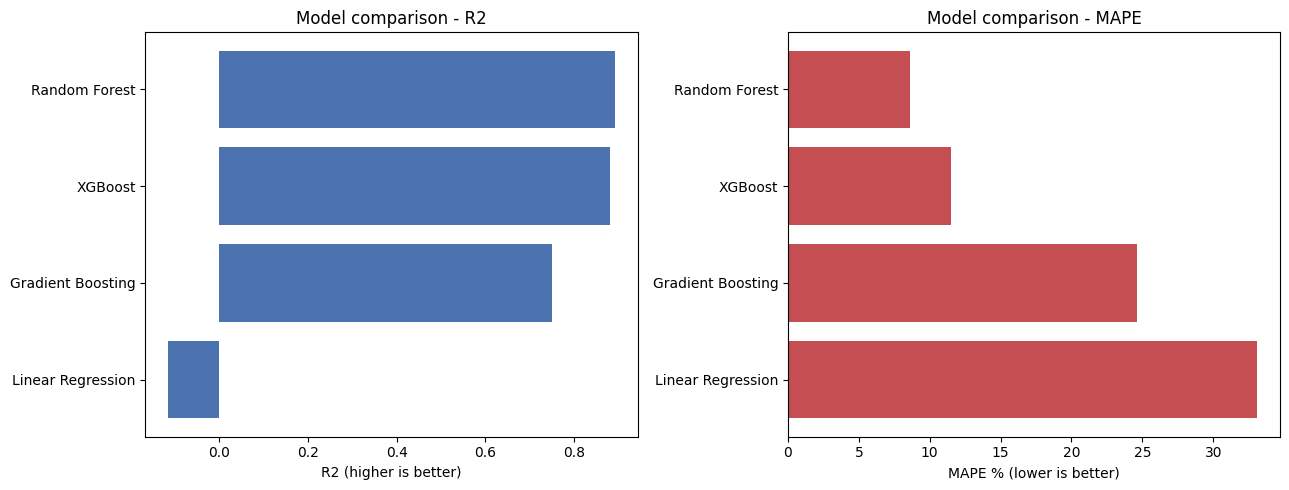

In [57]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].barh(results_df["Model"], results_df["R2"], color="#4C72B0")
axes[0].set_xlabel("R2 (higher is better)")
axes[0].set_title("Model comparison - R2")
axes[0].invert_yaxis()

axes[1].barh(results_df["Model"], results_df["MAPE (%)"], color="#C44E52")
axes[1].set_xlabel("MAPE % (lower is better)")
axes[1].set_title("Model comparison - MAPE")
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig("model_comparison.png", dpi=120)
plt.show()

In [58]:
best_row = results_df.iloc[0]
best_model_name = best_row["Model"]
best_model = fitted_models[best_model_name]

print("\n=== Best model ===")
print(f"Model : {best_model_name}")
print(f"R2    : {best_row['R2']:.3f}")
print(f"MAE   : {best_row['MAE (rupees)']:,.0f} rupees")
print(f"RMSE  : {best_row['RMSE (rupees)']:,.0f} rupees")
print(f"MAPE  : {best_row['MAPE (%)']:.1f}%")

# persist the winning model (preprocessing + regressor + log-target, all in one object)
import joblib
joblib.dump(best_model, "best_model.pkl")
print(f"\nSaved best model ({best_model_name}) to best_model.pkl")


=== Best model ===
Model : Random Forest
R2    : 0.892
MAE   : 941,532 rupees
RMSE  : 4,582,794 rupees
MAPE  : 8.6%

Saved best model (Random Forest) to best_model.pkl


In [59]:
# saving XGBoost

best_row = results_df.iloc[1]
m1=best_row['Model']
XGBoost_Model=fitted_models[m1]

print("\n=== Best model ===")
print(f"Model : {m1}")
print(f"R2    : {best_row['R2']:.3f}")
print(f"MAE   : {best_row['MAE (rupees)']:,.0f} rupees")
print(f"RMSE  : {best_row['RMSE (rupees)']:,.0f} rupees")
print(f"MAPE  : {best_row['MAPE (%)']:.1f}%")

# persist the winning model (preprocessing + regressor + log-target, all in one object)
import joblib
joblib.dump(XGBoost_Model, "XGBoost_Model.pkl")
print(f"\nSaved XGBoost model ({best_model_name}) to XGBoost_Model.pkl")


=== Best model ===
Model : XGBoost
R2    : 0.879
MAE   : 1,277,897 rupees
RMSE  : 4,842,355 rupees
MAPE  : 11.5%

Saved XGBoost model (Random Forest) to XGBoost_Model.pkl


In [60]:
# saving final data

df.to_csv("house_prices_cleaned.csv", index=False)
print("Saved house_prices_cleaned.csv")


Saved house_prices_cleaned.csv


In [63]:
df1=pd.read_csv(f"/content/house_prices_cleaned.csv")
df1

,location,Transaction,Furnishing,facing,Ownership,price_clean,area_sqft,area_source,current_floor,total_floors,bathroom,balcony,bhk
0,thane,Resale,Unfurnished,Unknown,Unknown,4200000.0,500.0,carpet,10.0,11.0,1.0,2.0,1.0
1,thane,Resale,Semi-Furnished,East,Freehold,9800000.0,473.0,carpet,3.0,22.0,2.0,2.0,2.0
2,thane,Resale,Unfurnished,East,Freehold,14000000.0,779.0,carpet,10.0,29.0,2.0,2.0,2.0
3,thane,Resale,Unfurnished,Unknown,Unknown,2500000.0,530.0,carpet,1.0,3.0,1.0,1.0,1.0
4,thane,Resale,Unfurnished,West,Co-operative Society,16000000.0,635.0,carpet,20.0,42.0,2.0,2.0,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
171017,zirakpur,New Property,Semi-Furnished,East,Freehold,6300000.0,1953.0,super,2.0,4.0,3.0,3.0,3.0
171018,zirakpur,Resale,Unfurnished,North - East,Unknown,5500000.0,1680.0,super,4.0,6.0,3.0,3.0,3.0
171019,zirakpur,Resale,Furnished,East,Freehold,7600000.0,1250.0,carpet,1.0,3.0,3.0,2.0,3.0
171020,zirakpur,Resale,Semi-Furnished,Unknown,Unknown,3000000.0,709.0,super,2.0,2.0,2.0,2.0,2.0
